# 🌸 Iris Flower Classification
### OIBSIP Internship – Task 1
**Author:** Youssef Hatem Mohamed Bahig  
**Program:** AICTE Oasis Infobyte Internship  

---

## 📌 Objective
Train a machine learning model that learns from iris flower measurements and classifies them into:
- 🌸 **Setosa**
- 🌺 **Versicolor**
- 🌼 **Virginica**

---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## Step 2 — Load the Dataset

In [2]:
URL = 'https://raw.githubusercontent.com/amankharwal/Website-data/master/IRIS.csv'
df = pd.read_csv(URL)

print('✅ Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


---
## Step 3 — Exploratory Data Analysis (EDA)

In [3]:
# Dataset Info
print('📋 Dataset Info:')
df.info()

📋 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
# Basic Statistics
print('📈 Statistical Summary:')
df.describe()

📈 Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Species Distribution
print('🌸 Species Count:')
print(df['species'].value_counts())

print('\n❓ Missing Values:')
print(df.isnull().sum())

🌸 Species Count:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

❓ Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


---
## Step 4 — Visualizations

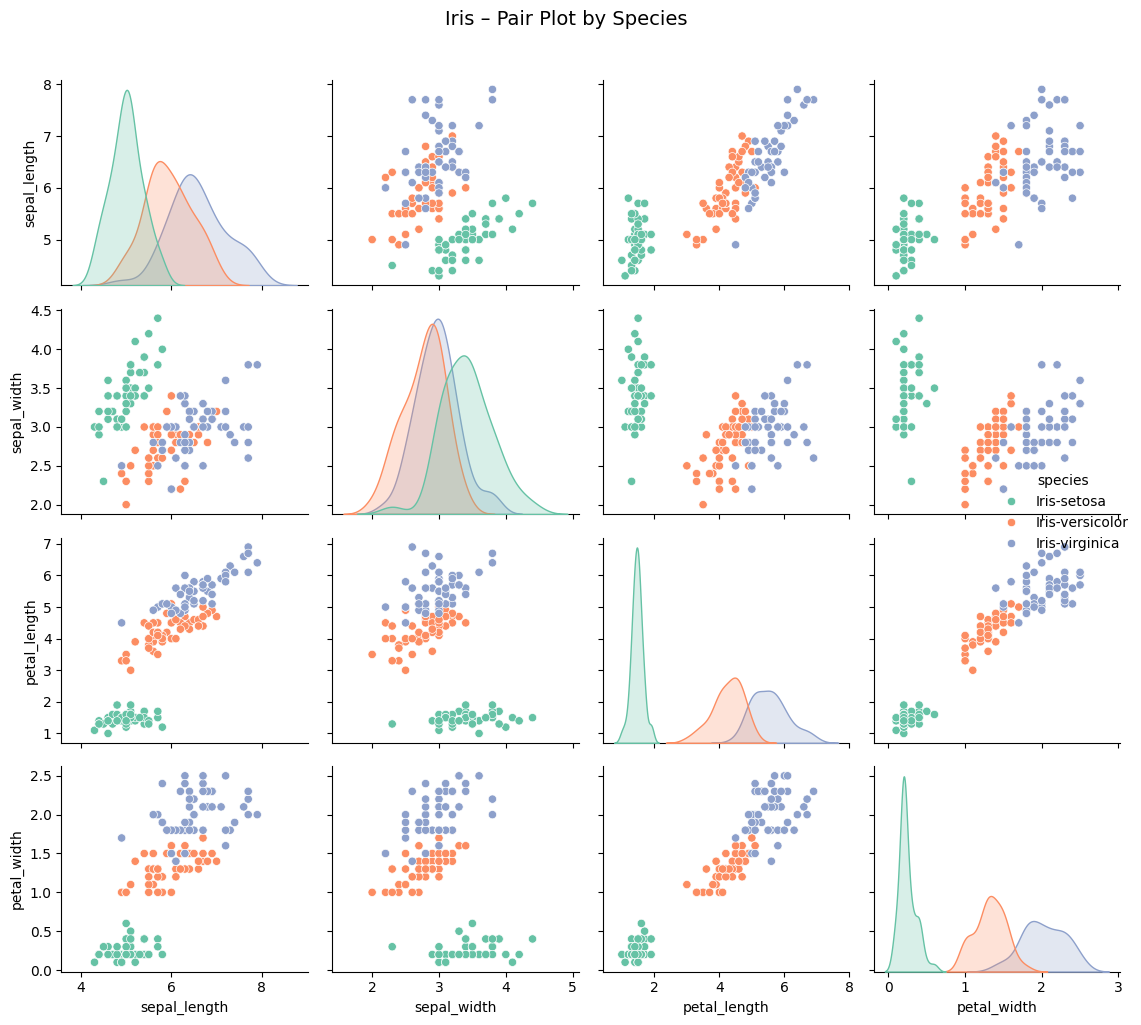

In [6]:
# 4a. Pair Plot
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde')
plt.suptitle('Iris – Pair Plot by Species', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

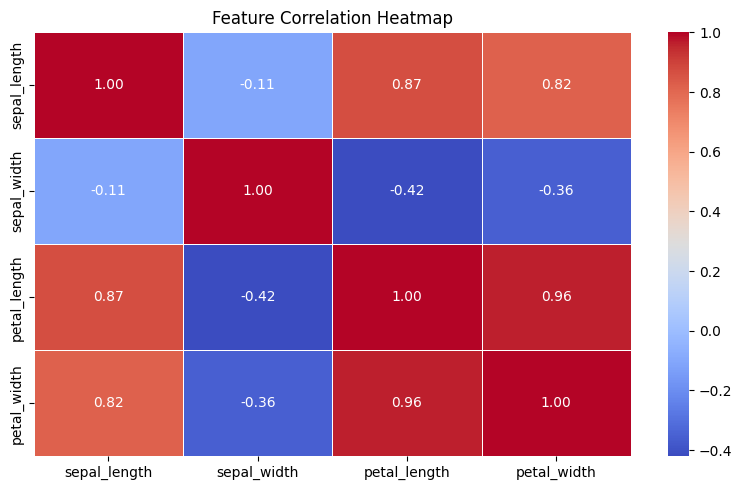

In [7]:
# 4b. Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.drop('species', axis=1).corr(),
    annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

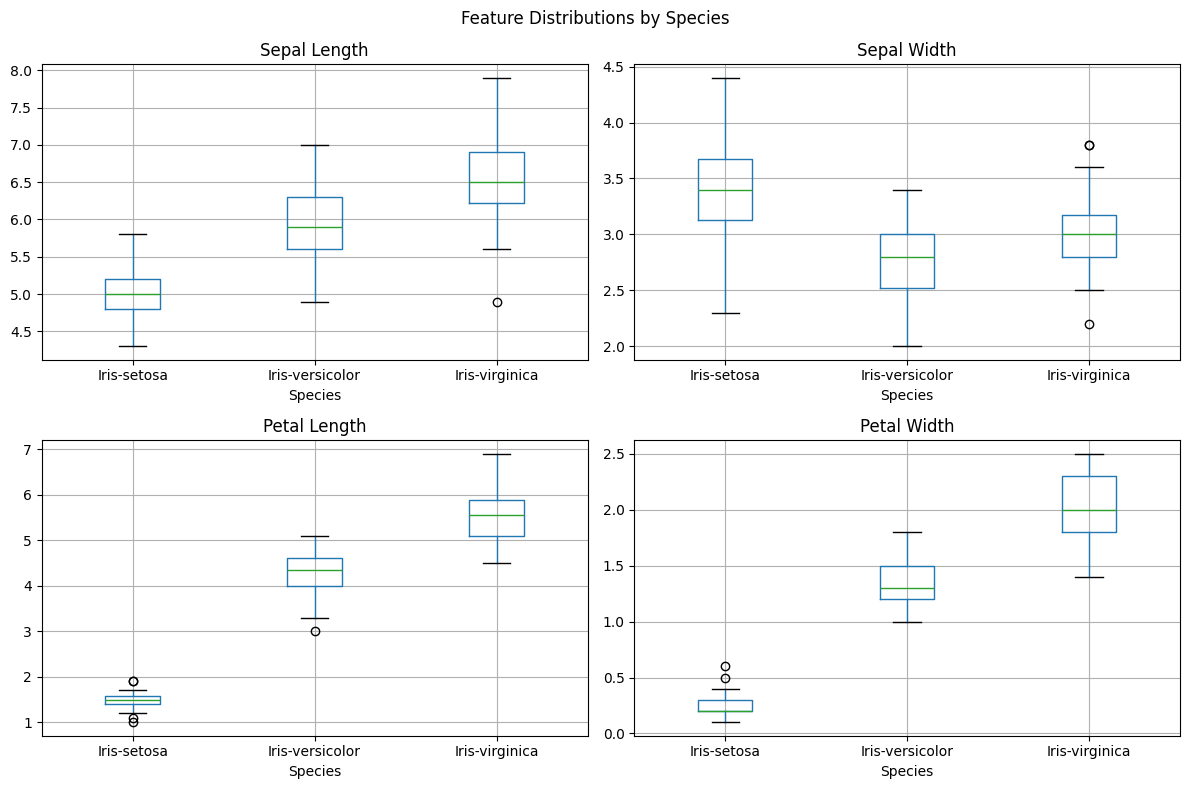

In [8]:
# 4c. Boxplots per feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, feat in zip(axes.flatten(), features):
    df.boxplot(column=feat, by='species', ax=ax)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Species')

plt.suptitle('Feature Distributions by Species')
plt.tight_layout()
plt.show()

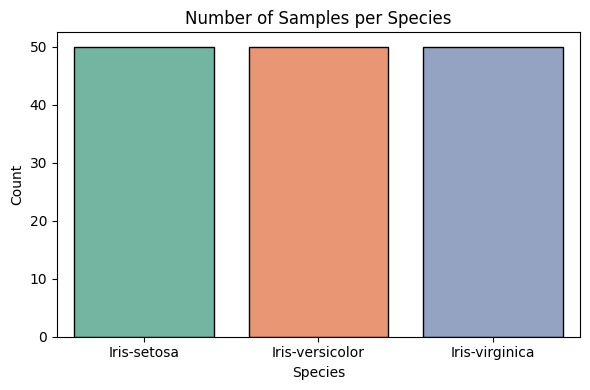

In [9]:
# 4d. Species Count Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(x='species', data=df, palette='Set2', edgecolor='black')
plt.title('Number of Samples per Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
## Step 5 — Preprocessing

In [10]:
# Features and Target
X = df.drop('species', axis=1)

le = LabelEncoder()
y  = le.fit_transform(df['species'])   # setosa=0, versicolor=1, virginica=2

print('🏷️ Label Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'   {cls} → {i}')

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n📦 Training samples : {X_train.shape[0]}')
print(f'📦 Testing  samples : {X_test.shape[0]}')

🏷️ Label Encoding:
   Iris-setosa → 0
   Iris-versicolor → 1
   Iris-virginica → 2

📦 Training samples : 120
📦 Testing  samples : 30


---
## Step 6 — Train & Evaluate Models

In [11]:
models = {
    'Logistic Regression'          : LogisticRegression(max_iter=200),
    'Decision Tree'                : DecisionTreeClassifier(random_state=42),
    'Random Forest'                : RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine (SVM)' : SVC(kernel='rbf', C=1.0, gamma='scale'),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds    = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    results[name] = accuracy

    print('=' * 55)
    print(f'🤖 {name}')
    print(f'   Accuracy : {accuracy * 100:.2f}%')
    print(classification_report(y_test, preds, target_names=le.classes_))

🤖 Logistic Regression
   Accuracy : 96.67%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

🤖 Decision Tree
   Accuracy : 93.33%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

🤖 Random Forest
   Accuracy : 90.00%
                 precision    recall  f1-score   support

    Iris-setosa      

---
## Step 7 — Compare Model Accuracies

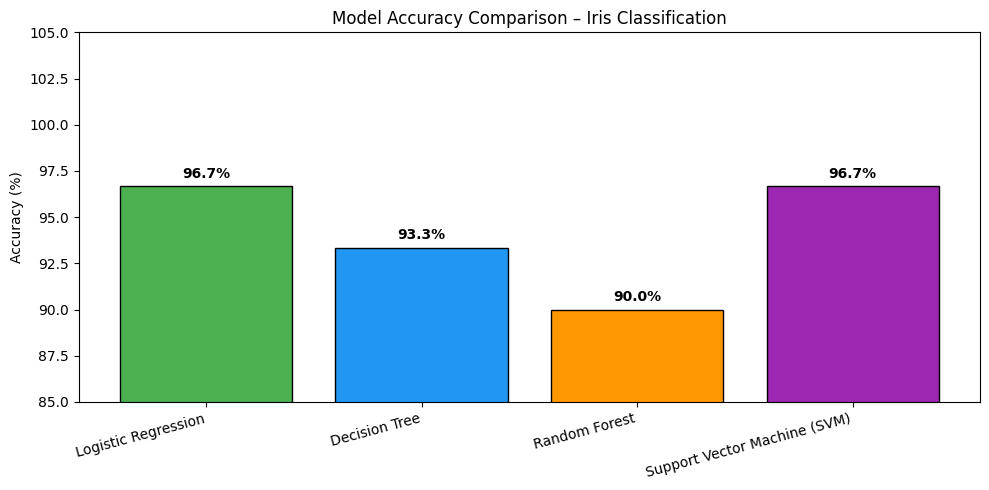

In [12]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    results.keys(),
    [v * 100 for v in results.values()],
    color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'],
    edgecolor='black'
)
plt.ylim(85, 105)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison – Iris Classification')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, results.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val*100:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )

plt.tight_layout()
plt.show()

---
## Step 8 — Confusion Matrix (Best Model)

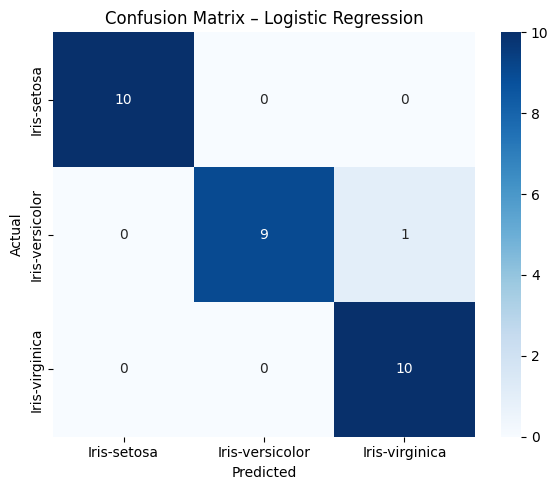


🏆 Best Model: Logistic Regression
   Accuracy  : 96.67%


In [13]:
best_name  = max(results, key=results.get)
best_model = models[best_name]
best_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title(f'Confusion Matrix – {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f'\n🏆 Best Model: {best_name}')
print(f'   Accuracy  : {results[best_name]*100:.2f}%')

---
## Step 9 — Predict a New Sample

In [14]:
# Change these values to test your own flower measurements
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

prediction = best_model.predict(sample)
predicted_species = le.inverse_transform(prediction)[0]

print('🔮 Prediction Demo')
print(f'   Sepal Length : {sample["sepal_length"].values[0]} cm')
print(f'   Sepal Width  : {sample["sepal_width"].values[0]} cm')
print(f'   Petal Length : {sample["petal_length"].values[0]} cm')
print(f'   Petal Width  : {sample["petal_width"].values[0]} cm')
print(f'\n   🌸 Predicted Species → {predicted_species.upper()}')

🔮 Prediction Demo
   Sepal Length : 5.1 cm
   Sepal Width  : 3.5 cm
   Petal Length : 1.4 cm
   Petal Width  : 0.2 cm

   🌸 Predicted Species → IRIS-SETOSA


---
## Step 10 — Final Summary

In [15]:
print('=' * 55)
print('               FINAL RESULTS SUMMARY')
print('=' * 55)
for name, acc in results.items():
    marker = '✅ BEST' if name == best_name else '      '
    print(f'  {marker}  {name:<35} {acc*100:.2f}%')
print('=' * 55)
print('\n✅ Task 1 Complete – Ready for Submission!')

               FINAL RESULTS SUMMARY
  ✅ BEST  Logistic Regression                 96.67%
          Decision Tree                       93.33%
          Random Forest                       90.00%
          Support Vector Machine (SVM)        96.67%

✅ Task 1 Complete – Ready for Submission!
